In [8]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Load all monthly JSON files into a single DataFrame
data_dir = Path("carbon_export")
frames = []
for path in sorted(data_dir.glob("*.json")):
    month = path.stem  # e.g. "2025-02"
    with open(path) as f:
        records = json.load(f)
    df = pd.DataFrame(records)
    df["month"] = month
    frames.append(df)

df = pd.concat(frames, ignore_index=True)
df["totalEmissions"] = df["scope1"] + df["scope2"] + df["scope3"]
df["month"] = pd.to_datetime(df["month"])

df = df[df["resourceGroup"] == "felixswarmchestrate"]

print(f"Loaded {len(df)} rows across {df['month'].nunique()} months")
df.head()

Loaded 350 rows across 7 months


,resourceId,resourceGroup,resourceType,location,resourceName,scope1,scope2,scope3,month,totalEmissions
100,/subscriptions/3b7f0d07-2848-4c7c-87d3-074743a...,felixswarmchestrate,microsoft.network/publicipaddresses,east us,fog-energy-worker-pip,0.000144,0.0,0.010107,2025-08-01,0.010251
101,/subscriptions/3b7f0d07-2848-4c7c-87d3-074743a...,felixswarmchestrate,microsoft.network/publicipaddresses,east us,cloud-energy-worker-pip,0.000144,0.0,0.010102,2025-08-01,0.010246
102,/subscriptions/3b7f0d07-2848-4c7c-87d3-074743a...,felixswarmchestrate,microsoft.network/publicipaddresses,east us,cloud-energy-master-pip,0.000129,0.0,0.009065,2025-08-01,0.009194
103,/subscriptions/3b7f0d07-2848-4c7c-87d3-074743a...,felixswarmchestrate,microsoft.network/publicipaddresses,east us,fog-energy-master-pip,0.000129,0.0,0.009065,2025-08-01,0.009194
104,/subscriptions/3b7f0d07-2848-4c7c-87d3-074743a...,felixswarmchestrate,microsoft.network/publicipaddresses,east us,knowledge-base-pip,0.000129,0.0,0.009043,2025-08-01,0.009172


In [9]:
# Overview: basic stats
print(f"Date range: {df['month'].min():%Y-%m} to {df['month'].max():%Y-%m}")
print(f"Resources per month:")
print(df.groupby("month").size().to_string())
print()
print("Total emissions by scope (kgCO2e):")
for scope in ["scope1", "scope2", "scope3"]:
    print(f"  {scope}: {df[scope].sum():.4f}")
print(f"  total:  {df['totalEmissions'].sum():.4f}")

Date range: 2025-08 to 2026-02
Resources per month:
month
2025-08-01    88
2025-09-01    77
2025-10-01    35
2025-11-01    45
2025-12-01    27
2026-01-01    46
2026-02-01    32

Total emissions by scope (kgCO2e):
  scope1: 0.0427
  scope2: 0.0000
  scope3: 2.8009
  total:  2.8437


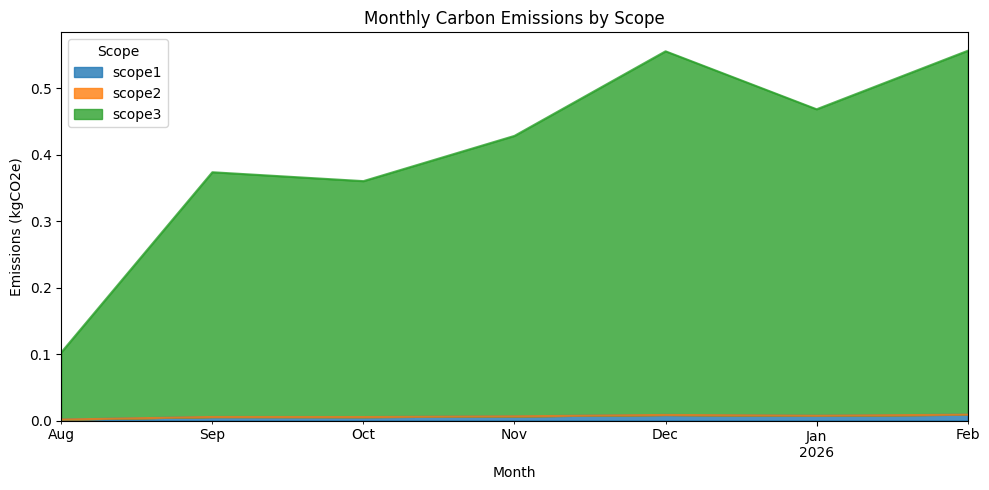

In [10]:
# Time trends: monthly emissions stacked by scope
monthly = df.groupby("month")[["scope1", "scope2", "scope3"]].sum()

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot.area(ax=ax, stacked=True, alpha=0.8)
ax.set_title("Monthly Carbon Emissions by Scope")
ax.set_ylabel("Emissions (kgCO2e)")
ax.set_xlabel("Month")
ax.legend(title="Scope")
plt.tight_layout()
plt.show()

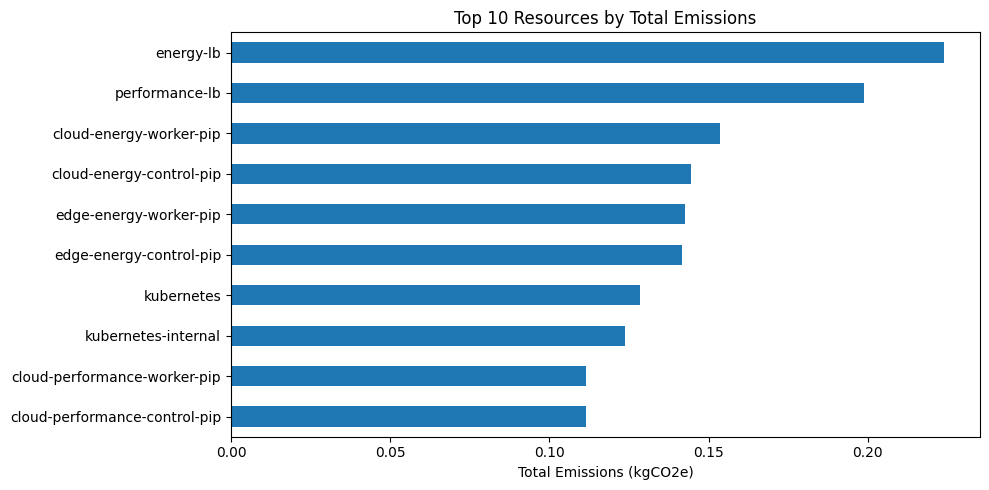

In [11]:
# Top 10 emitters by total emissions across all months
top_emitters = (
    df.groupby("resourceName")["totalEmissions"]
    .sum()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
top_emitters.plot.barh(ax=ax)
ax.set_title("Top 10 Resources by Total Emissions")
ax.set_xlabel("Total Emissions (kgCO2e)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

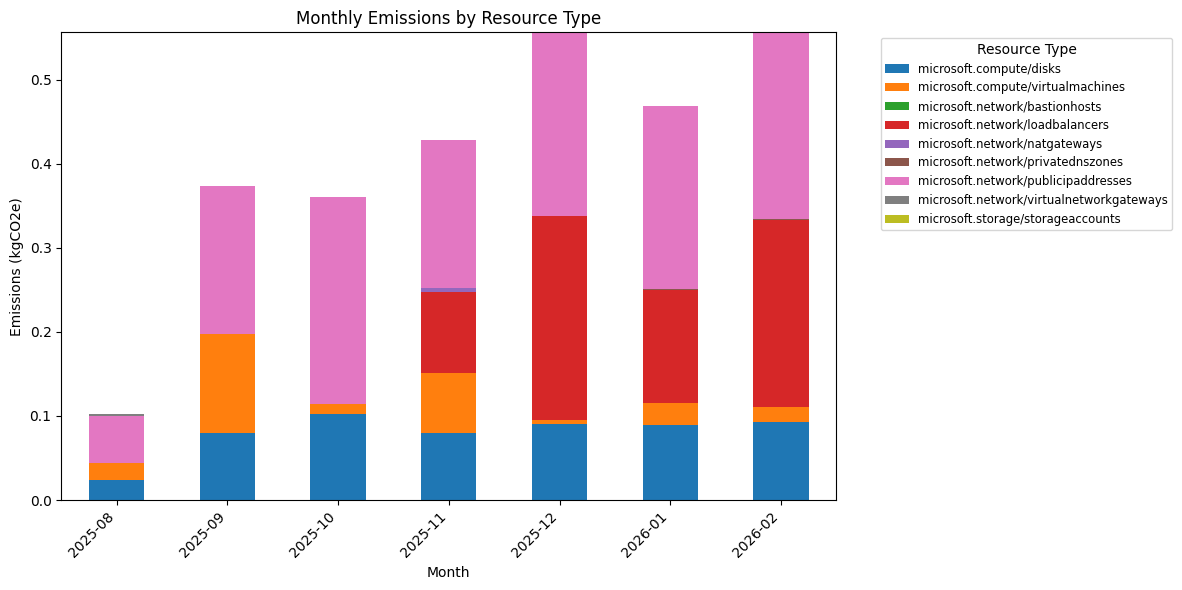

In [12]:
# Breakdown by resourceType: monthly stacked bar chart
by_type = df.groupby(["month", "resourceType"])["totalEmissions"].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
labels = [d.strftime("%Y-%m") for d in by_type.index]
by_type.index = labels
by_type.plot.bar(ax=ax, stacked=True)
ax.set_title("Monthly Emissions by Resource Type")
ax.set_ylabel("Emissions (kgCO2e)")
ax.set_xlabel("Month")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Resource Type", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()
plt.show()

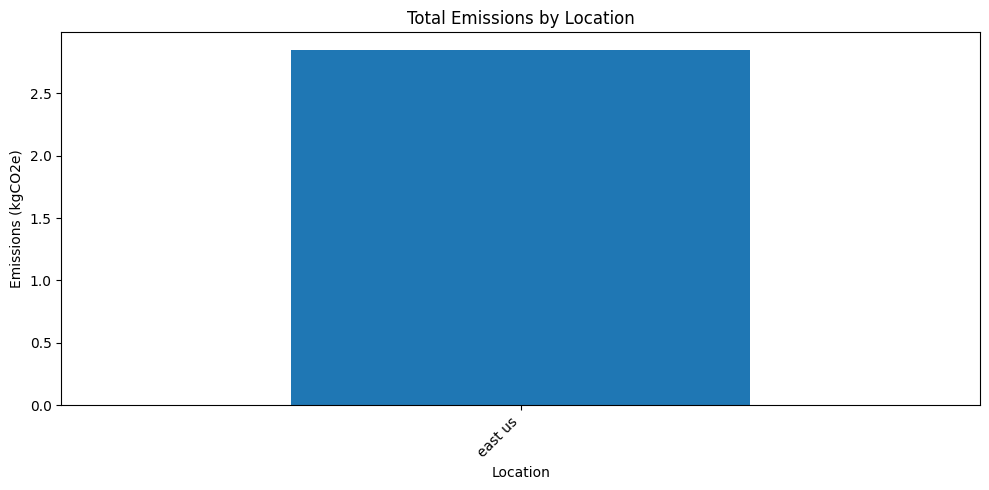

In [13]:
# Breakdown by location
by_location = df.groupby("location")["totalEmissions"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
by_location.plot.bar(ax=ax)
ax.set_title("Total Emissions by Location")
ax.set_ylabel("Emissions (kgCO2e)")
ax.set_xlabel("Location")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

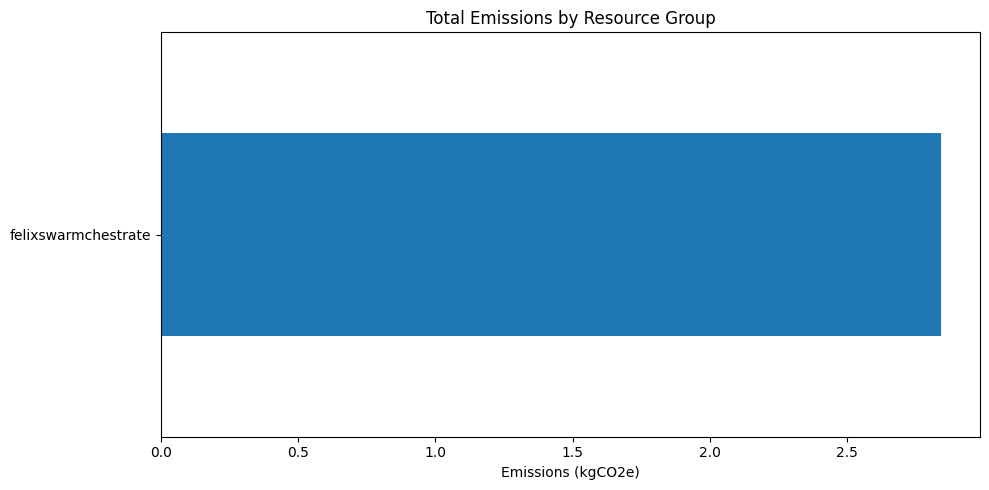

In [14]:
# Breakdown by resourceGroup
by_rg = df.groupby("resourceGroup")["totalEmissions"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(by_rg) * 0.4)))
by_rg.sort_values().plot.barh(ax=ax)
ax.set_title("Total Emissions by Resource Group")
ax.set_xlabel("Emissions (kgCO2e)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()